In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'ne_10m_admin1_states_provinces'
collection_id = 'vector-ne-10m-admin1-states_provinces'

# Stac collection title
collection_title = 'Natural Earth States and Provinces'

# Stac collection description
description = '''Natural Earth (ne) Admin 1 (state or province-level) data.'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'adm1_code'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

filepath = '/data/vector/ne_10m_cultural/10m_cultural/ne_10m_admin_1_states_provinces.shp'
gdf_complete = geopandas.read_file(filepath)
gdf_complete[dt_col] = datetime(2022, 5, 12, tzinfo=pytz.utc)

assert(~gdf_complete[id_col].duplicated().any())

gdf_complete.tail(2)

CPU times: total: 8.39 s
Wall time: 11.8 s


,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry,timestamp
4594,Admin-1 states provinces,10,MLT-5940,5940,MT-34,None,MT,3,Msida,None,...,None,None,None,None,None,None,None,None,"POLYGON ((14.48663 35.88636, 14.48231 35.88979...",2022-05-12 00:00:00+00:00
4595,Admin-1 states provinces,10,MLT-5951,5951,MT-03,None,MT,3,Birgu,None,...,None,None,None,None,None,None,None,None,"POLYGON ((14.52126 35.88711, 14.51537 35.89113...",2022-05-12 00:00:00+00:00


In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x220035851d0>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'ne_10m_admin1_states_provinces',
 'collection_id': 'vector-ne-10m-admin1-states_provinces',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/ne_10m_admin1_states_provinces',
 'grid_directory': 'data/vectorstore/ne_10m_admin1_states_provinces/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/ne_10m_admin1_states_provinces/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/ne_10m_admin1_states_provinces/grid=World(4326)/index',
 'dt_col': 'timestamp',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'adm1_code',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['timestamp', 'adm1_code'],
 'max_level': 26,
 'targe

# Chunked successive ingestion

In [4]:
%%time
n_chunks = 1
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

Chunk 0
df_root 4596
Time for indexing the root of each unique geometry in seconds 0.055
cannot call `vectorize` on size 0 inputs unless `otypes` is set
Failed to use numpy. Switching to pandas
distributed over 1 partitions
Time for creating partitions in seconds 0.055


C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)


Time for writing GeoDataFrame to GeoParquet partitions 0.348
CPU times: total: 203 ms
Wall time: 419 ms


In [5]:
%%time
vs.unify_schemas()

Time for unify_schemas 0.136
CPU times: total: 62.5 ms
Wall time: 136 ms


In [6]:
%%time
vs.defrag()

Time for defragging 0.505
CPU times: total: 312 ms
Wall time: 505 ms


In [7]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
level 1
source partition          target partition          records stay    records move   
level 2
source partition          target partition          records stay    records move   
level 3
source partition          target partition          records stay    records move   
level 4
source partition          target partition          records stay    records move   
level 5
source partition          target partition          records stay    records move   
level 6
source partition          target partition          records stay    records move   
level 7
source partition          target partition          records stay    records move   
level 8
source partition          target partition          records stay    records move   
level 9
source partition          target partition          records stay    records move   
level 10
source partition          target partition          records stay    rec

In [8]:
%%time
vs.defrag()

Time for defragging 0.491
CPU times: total: 281 ms
Wall time: 491 ms


In [9]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [10]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 31.2 ms
Wall time: 46 ms


,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,name_local,type,type_en,code_local,code_hasc,note,hasc_maybe,region,region_cod,provnum_ne,gadm_level,check_me,datarank,abbrev,postal,area_sqkm,sameascity,labelrank,name_len,mapcolor9,mapcolor13,fips,fips_alt,woe_id,woe_label,woe_name,latitude,longitude,sov_a3,adm0_a3,adm0_label,admin,geonunit,gu_a3,gn_id,gn_name,gns_id,gns_name,gn_level,gn_region,gn_a1_code,region_sub,sub_code,gns_level,gns_lang,gns_adm1,gns_region,min_label,max_label,min_zoom,wikidataid,name_ar,name_bn,name_de,name_en,name_es,name_fr,name_el,name_hi,name_hu,name_id,name_it,name_ja,name_ko,name_nl,name_pl,name_pt,name_ru,name_sv,name_tr,name_vi,name_zh,ne_id,name_he,name_uk,name_ur,name_fa,name_zht,FCLASS_ISO,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry,timestamp,_root,grid,spatial_partition
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,int64,object,int64,object,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,float64,int64,int64,int64,object,object,float64,int64,int64,int64,int64,int64,object,object,float64,object,object,float64,float64,object,object,int64,object,object,object,float64,object,float64,object,float64,object,object,object,object,float64,object,object,object,float64,float64,float64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,geometry,"datetime64[us, UTC]",object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

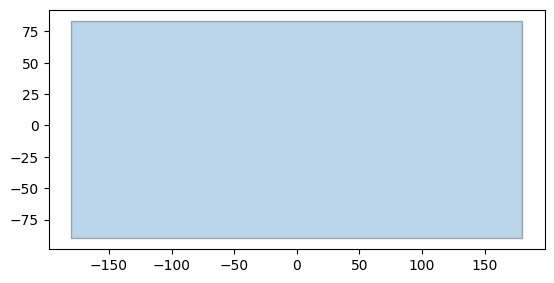

In [11]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('claimed_access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('claimed_secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('claimed_endpoint_url', '')
# S3 access url
private_endpoint_url = os.getenv('claimed_private_endpoint_url', '')
# S3 bucket
bucket = os.getenv('claimed_bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/ne_10m_admin1_states_provinces/grid=World(4326)/geoparquet/spatial_partition=0q/cbaddf40f151443294da64e910f74a9c.parquet
schema.names ['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2', 'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt', 'name_local', 'type', 'type_en', 'code_local', 'code_hasc', 'note', 'hasc_maybe', 'region', 'region_cod', 'provnum_ne', 'gadm_level', 'check_me', 'datarank', 'abbrev', 'postal', 'area_sqkm', 'sameascity', 'labelrank', 'name_len', 'mapcolor9', 'mapcolor13', 'fips', 'fips_alt', 'woe_id', 'woe_label', 'woe_name', 'latitude', 'longitude', 'sov_a3', 'adm0_a3', 'adm0_label', 'admin', 'geonunit', 'gu_a3', 'gn_id', 'gn_name', 'gns_id', 'gns_name', 'gn_level', 'gn_region', 'gn_a1_code', 'region_sub', 'sub_code', 'gns_level', 'gns_lang', 'gns_adm1', 'gns_region', 'min_label', 'max_label', 'min_zoom', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_en', 'name_es', 'name_fr', 'name_el', 'name_h

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/ne_10m_admin1_states_provinces/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-ne-10m-admin1-states_provinces'